In [1]:
import numpy as np
import pandas as pd
from pathlib import Path


dataset_path = Path("../dataset")
raw_data_path = dataset_path / "raw_data"
reference_path = raw_data_path / "REFERENCE.csv"

labels = pd.read_csv(
    reference_path,
    header=None,
    names=["record", "label"]
)


TARGET_LENGTH = 9000


def preprocess_ecg(ecg, target_length=TARGET_LENGTH):
    """
    Convert an ECG signal to a fixed length.

    Input:
        ecg: 1D numpy array

    Output:
        processed_ecg: 1D numpy array with target_length samples
    """

    ecg = np.asarray(ecg).flatten()

    current_length = len(ecg)

    # Case 1: ECG is shorter than target length
    if current_length < target_length:

        processed_ecg = np.pad(
            ecg,
            (0, target_length - current_length),
            mode="constant",
            constant_values=0
        )

    # Case 2: ECG is exactly target length
    elif current_length == target_length:

        processed_ecg = ecg.copy()

    # Case 3: ECG is longer than target length
    else:

        # For now, take the first 9000 samples
        processed_ecg = ecg[:target_length]

    return processed_ecg

In [2]:
from scipy.io import loadmat


raw_data_mat = list(raw_data_path.rglob("*.mat"))
lengths = []

for file in raw_data_mat:
    data = loadmat(file)
    ecg = data["val"]

    signal_length = ecg.shape[1]
    lengths.append(signal_length)

lengths = np.array(lengths)

exact_30 = np.sum(lengths == 9000)
labels["length_samples"] = lengths

In [3]:
short_record = labels.loc[
    labels["length_samples"] < 9000, "record"
].iloc[0]

exact_record = labels.loc[
    labels["length_samples"] == 9000, "record"
].iloc[0]

long_record = labels.loc[
    labels["length_samples"] > 9000, "record"
].iloc[0]


print("Short ECG :", short_record)
print("30-sec ECG:", exact_record)
print("Long ECG  :", long_record)

Short ECG : A00/A00014
30-sec ECG: A00/A00001
Long ECG  : A00/A00003


In [4]:
from scipy.io import loadmat
import os


RAW_DATA_PATH = "../dataset/raw_data"


def load_ecg(record):
    """
    Load an ECG record from the PhysioNet Challenge 2017 dataset.
    """

    file_path = os.path.join(
        RAW_DATA_PATH,
        record + ".mat"
    )

    data = loadmat(file_path)

    ecg = data["val"].flatten()

    return ecg

In [5]:
records_to_test = [
    short_record,
    exact_record,
    long_record
]

for record in records_to_test:

    ecg = load_ecg(record)

    processed_ecg = preprocess_ecg(ecg)

    print("-----------------------------")
    print("Record:", record)
    print("Original length:", len(ecg))
    print("Processed length:", len(processed_ecg))

-----------------------------
Record: A00/A00014
Original length: 5570
Processed length: 9000
-----------------------------
Record: A00/A00001
Original length: 9000
Processed length: 9000
-----------------------------
Record: A00/A00003
Original length: 18000
Processed length: 9000


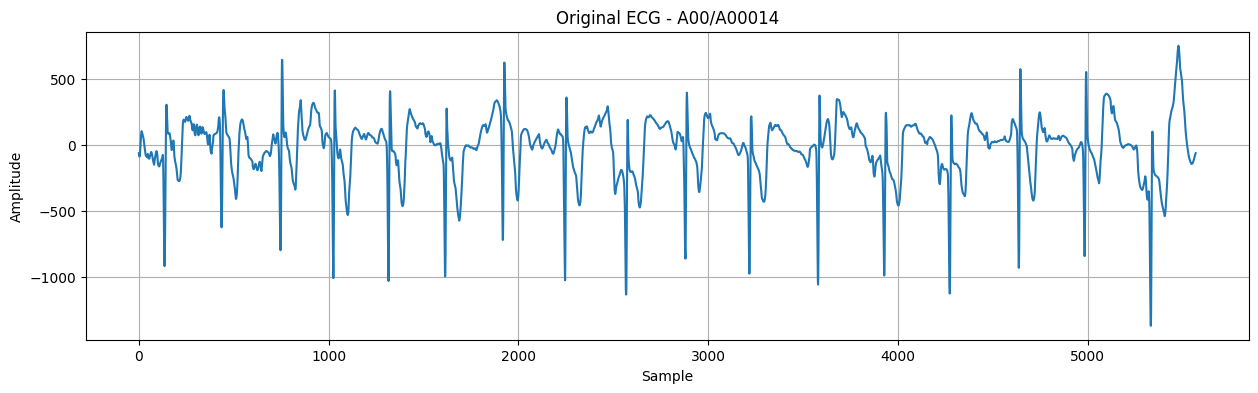

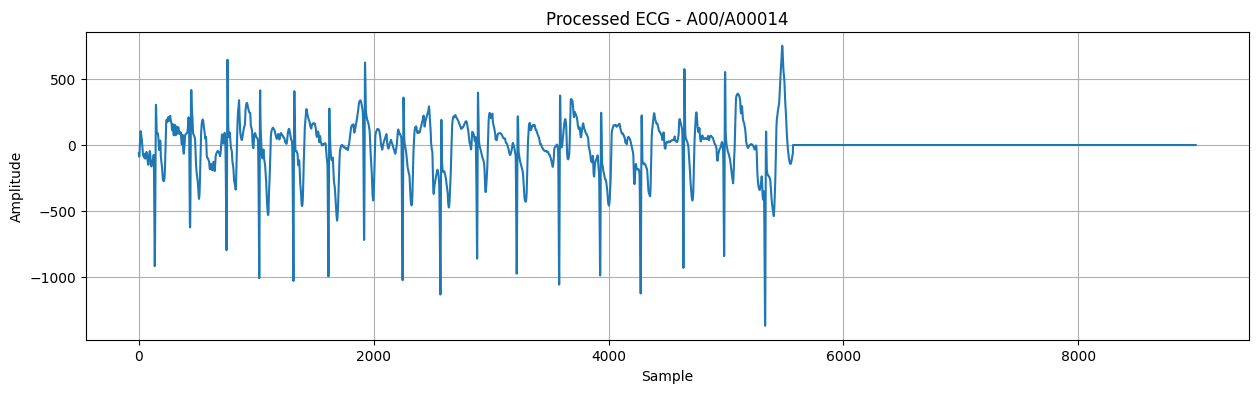

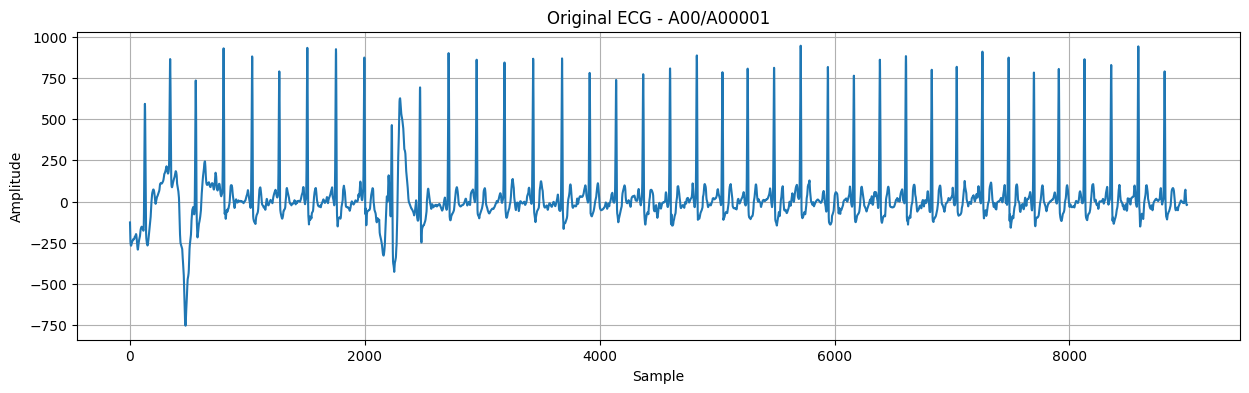

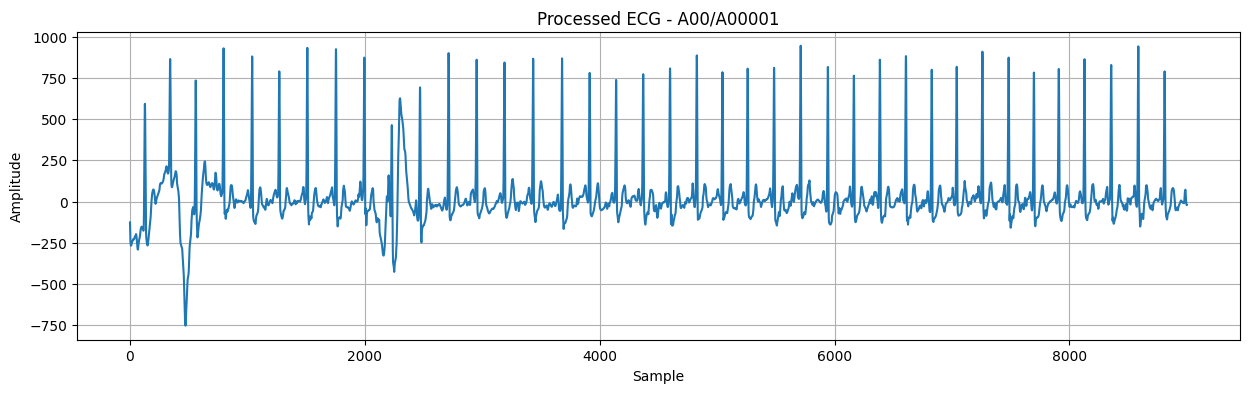

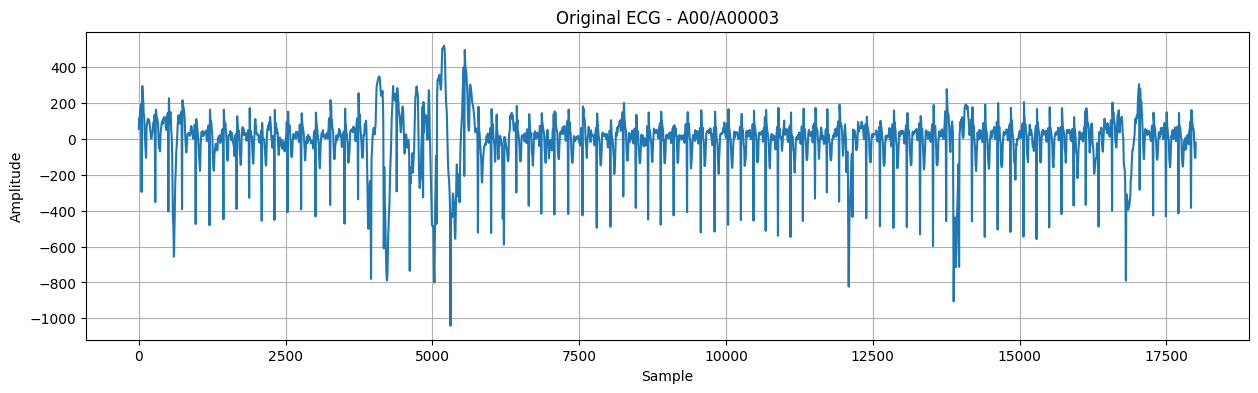

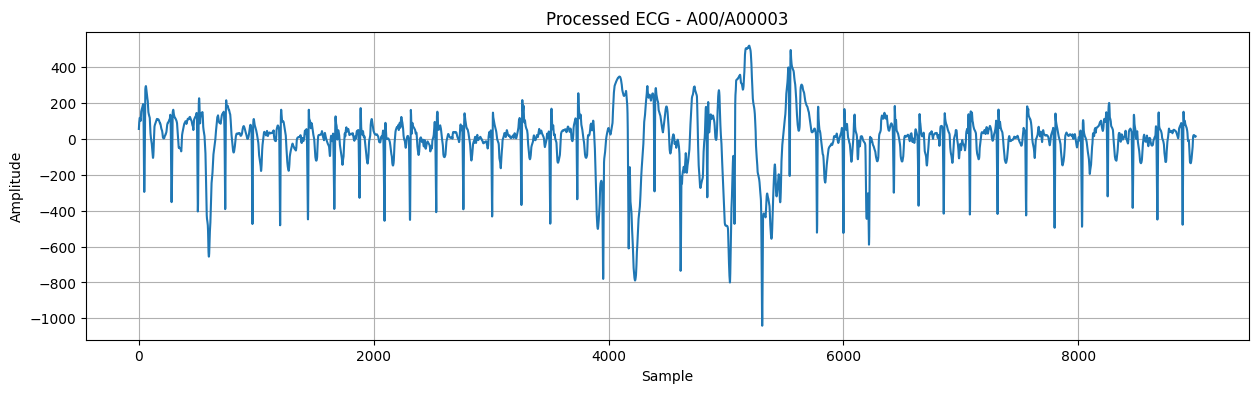

In [6]:
import matplotlib.pyplot as plt


for record in records_to_test:

    ecg = load_ecg(record)
    processed_ecg = preprocess_ecg(ecg)

    plt.figure(figsize=(15, 4))

    plt.plot(ecg, label="Original")

    plt.title(f"Original ECG - {record}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.grid()

    plt.show()


    plt.figure(figsize=(15, 4))

    plt.plot(processed_ecg)

    plt.title(f"Processed ECG - {record}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.grid()

    plt.show()